# <a id='toc1_'></a>[Section 4: Model Evaluation](#toc0_)

The goal of this notebook is to evaluate all the machine learning models that have been run and begin narrowing them down to select just 1 model. Remembering that my primary goal is to not only have high accuracy, but the model needs to be reliable and able to perform well with different hotel datasets.  Therefore, I will prioritize the lowest overfitting possible. The metrics that I will evaluate in this notebook are using classification reports to evaluate accuracy, precision, recall, and f-1 scores. I will also review ROC curves to calculate the Area under the Curve (AUC) scores for each model to evaluate the model overall. After selecting the “best” model, I will continue model evaluation with a confusion matrix to identify True Positives, False Positives, True Negatives, and False Negatives. This will help identify where the model performs well and incorrectly predicts cancellations. Lastly I will evaluate which features are most impactful to the model and what the model believes to be the driving factors to predicting if a reservation will cancel or not.



**Table of contents**<a id='toc0_'></a>    
- [Section 4: Model Evaluation](#toc1_)    
- [1. Set Up](#toc2_)    
- [2. Model Comparison](#toc3_)    
  - [2.1 Load Models and Train/Test](#toc3_1_1_)    
  - [2.2 Model Evaluation of random_forest_sm3](#toc3_1_2_)    
  - [2.3 Model Evaluation of XGBoost_model_sm](#toc3_1_3_)    
  - [2.4 Compare F1-scores overfitting](#toc3_1_4_)    
  - [2.5 Comparing Overfitting between Random Forest and XGBoost models:](#toc3_1_5_)    
- [3. Error Analysis](#toc4_)    
  - [3.1 Explore False Positives and False Negatives](#toc4_1_)    
  - [3.2 Explore Summary Statistics by Label for each feature](#toc4_2_)    
  - [3.3 Box Plot Distribution Exploration](#toc4_3_)    
- [4. Feature Importance](#toc5_)    
  - [4.1 Random Forest Feature Importance:](#toc5_1_1_)    
  - [4.2 Shapley Values](#toc5_2_)    
- [5. Summary](#toc6_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc2_'></a>[1. Set Up](#toc0_)

In [ ]:
# Standard imports
import numpy as np
import pandas as pd

# Plotting
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objs as go

# Modeling
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Lasso, Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

#Metrics 
from sklearn.metrics import f1_score, precision_score, recall_score, roc_curve, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay
import shap
from sklearn.inspection import permutation_importance
import lime
import lime.lime_tabular

# Balancing
from imblearn.over_sampling import SMOTE


from tempfile import mkdtemp
import joblib

In [2]:
# show all dataframe columns
pd.set_option('display.max_columns', None)
# set matplotlib global settings eg. figsize
plt.rcParams['figure.figsize'] = (8.0, 6.0)

In [49]:
# Import hotel_clean_df
final_df = pd.read_csv('../data/processed/final_df.csv')


In [50]:
final_df.head(5)

,is_canceled,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,is_repeated_guest,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,day_demand,los,arrival_year,arrival_month,arrival_dow,arrival_day,hotel_City Hotel,hotel_Resort Hotel,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Transient
0,0,342,27,0,0,2,0,0,1,0,0,3,0,0,0,0.0,0,0,122,0,2015,7,2,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1
1,0,737,27,0,0,2,0,0,1,0,0,4,0,0,0,0.0,0,0,122,0,2015,7,2,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1
2,0,7,27,0,1,1,0,0,1,0,0,0,0,0,0,75.0,0,0,122,1,2015,7,2,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1
3,0,13,27,0,1,1,0,0,1,0,0,0,1,0,0,75.0,0,0,122,1,2015,7,2,1,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1
4,0,14,27,0,2,2,0,0,1,0,0,0,1,0,0,98.0,0,1,122,2,2015,7,2,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1


In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114737 entries, 0 to 114736
Data columns (total 43 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   is_canceled                     114737 non-null  int64  
 1   lead_time                       114737 non-null  int64  
 2   arrival_date_week_number        114737 non-null  int64  
 3   stays_in_weekend_nights         114737 non-null  int64  
 4   stays_in_week_nights            114737 non-null  int64  
 5   adults                          114737 non-null  int64  
 6   children                        114737 non-null  int64  
 7   babies                          114737 non-null  int64  
 8   meal                            114737 non-null  int64  
 9   is_repeated_guest               114737 non-null  int64  
 10  previous_bookings_not_canceled  114737 non-null  int64  
 11  booking_changes                 114737 non-null  int64  
 12  agent           

# <a id='toc3_'></a>[2. Model Comparison](#toc0_)

Before diving into model evaluation, here is a summary table of the models that I've run:


| Model         | Train Score | Test Score | Hyperparameter C | K-Fold Cross Val | Max Iter | PCA |
|---------------|-------------|------------|------------------|------------------|----------|-----|
| log_reg_sm    | 79.90%      | 77.97%     | -                |   -              | -        | N   |
| log_reg_sm2   | 79.50%      | n/a        | C=1              |   5              | 1000     | N   |
| log_reg_sm3   | 79.90%      | 77.94%     | C=1              |   -              | 1000     | Y   |

| Model              | Train Score | Test Score | Precision | Recall  | f1-score | n_estimators | max_depth | min_samples_split | min_samples_leaf | class_weight |
|--------------------|-------------|------------|-----------|---------|----------|--------------|-----------|-------------------|------------------|--------------|
| random_forest_sm   | 99.08%      | 85.75%     | 83.57%    | 77.03%  | 80.16%   | 1000         | -         | -                 | -                | -            |
| random_forest_sm2  | 80.24%      | 79.80%     | 77.74%    | 64.44%  | 70.47%   | 1500         | 9         | 72                | 16               | balanced     |
| random_forest_sm3  | 81.91%      | 80.80%     | 78.58%    | 66.88%  | 72.26%   | 1500         | 11        | 60                | 1                | balanced     |

| Model              | Train Score | Test Score | Precision | Recall  | f1-score | n_estimators | max_depth | learning_rate | eval_metric |
|--------------------|-------------|------------|-----------|---------|----------|--------------|-----------|---------------|-------------|
| XGBoost_model_sm   | 86.44%      | 82.90%     | 79.54%    | 73.07%  | 76.17%   |              |           |               |             |
| XGBoost_model_sm2  | 88.98%      | 83.86%     | 81.04%    | 74.20%  | 77.47%   | 400          | 7         | 0.1           | auc         |
| XGBoost_model_sm3  | 90.80%      | 84.33%     | 81.56%    | 75.07%  | 78.18%   | 300          | 7         | 0.2           | auc         |

Remembering that my goal is to identify models with the least overfitting and high f1-scores. Based on the models, for my next steps I will evaluate the random_forest_sm3 and XGBoost_model_sm baseline models further. 
1. ROC and AUC for random_forest_sm3
2. ROC and AUC for XGBoost_model_sm

## <a id='toc3_1_1_'></a>[2.1 Load Models and Train/Test](#toc0_)

In [ ]:
# Load the top two selected models:
random_forest_sm3 = joblib.load('../models/trained/random_forest_sm3.pkl')

XGBoost_model_sm = joblib.load('../models/trained/XGBoost_model_sm.pkl')


In [ ]:
# Load X and y train and tests for evaluation 

X_test = joblib.load('../data/processed/X_test.joblib')
X_test_sm_ss = joblib.load('../data/processed/X_test_sm_ss.joblib')

X_train = joblib.load('../data/processed/X_train.joblib')
X_train_sm = joblib.load('../data/processed/X_train_sm.joblib')
X_train_sm_ss = joblib.load('../data/processed/X_train_sm_ss.joblib')

y_test = joblib.load('../data/processed/y_test.joblib')
y_train_sm = joblib.load('../data/processed/y_train_sm.joblib')

## <a id='toc3_1_2_'></a>[2.2 Model Evaluation of random_forest_sm3](#toc0_)

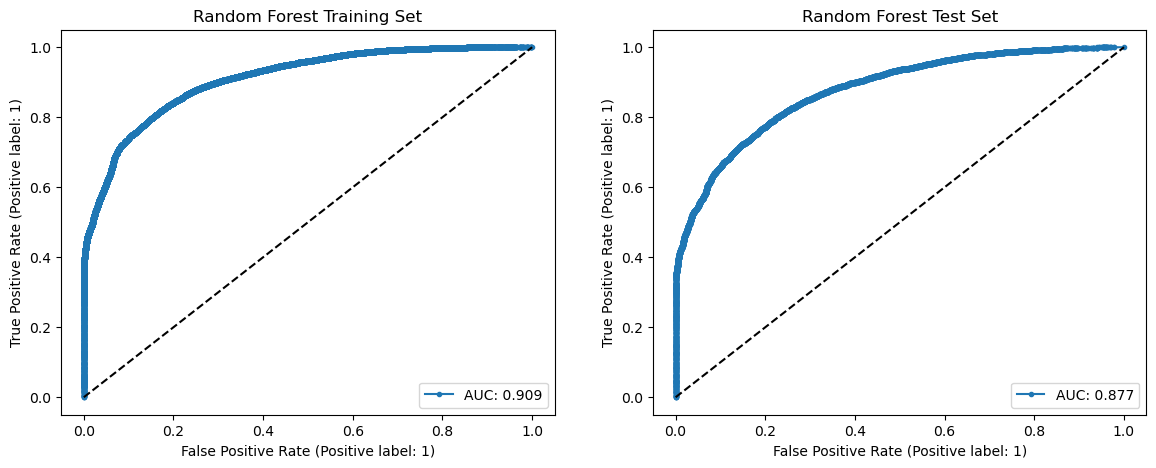

Training Set AUC: 0.909
Test Set AUC: 0.877


In [ ]:
#Predict probabilities
y_proba_train = random_forest_sm3.predict_proba(X_train_sm_ss)[:,1]
y_proba_test = random_forest_sm3.predict_proba(X_test_sm_ss)[:,1]

# Score (AUC)
rf_auc_train = np.round(roc_auc_score(y_train_sm, y_proba_train),3)
rf_auc_test = np.round(roc_auc_score(y_test, y_proba_test),3)

# Set up subplot structure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Labels
train_label = f"AUC: {rf_auc_train}"
test_label = f"AUC: {rf_auc_test}"

# Using RocCurveDisplay - pass in the fitted model, then the X data, then the y data
RocCurveDisplay.from_estimator(random_forest_sm3, X_train_sm_ss, y_train_sm, ax=axes[0], marker=".", label=train_label)
RocCurveDisplay.from_estimator(random_forest_sm3, X_test_sm_ss, y_test, ax=axes[1], marker=".", label=test_label)

axes[0].plot([0, 1], [0, 1], color="black", linestyle="--")
axes[1].plot([0, 1], [0, 1], color="black", linestyle="--")
axes[0].set_title("Random Forest Training Set")
axes[1].set_title("Random Forest Test Set")


plt.show()

print(f"Training Set AUC: {rf_auc_train}")
print(f"Test Set AUC: {rf_auc_test}")

The area under the curve (AUC) for the random_forest_sm3 model is 87.7% with slight overfitting.

## <a id='toc3_1_3_'></a>[2.3 Model Evaluation of XGBoost_model_sm](#toc0_)

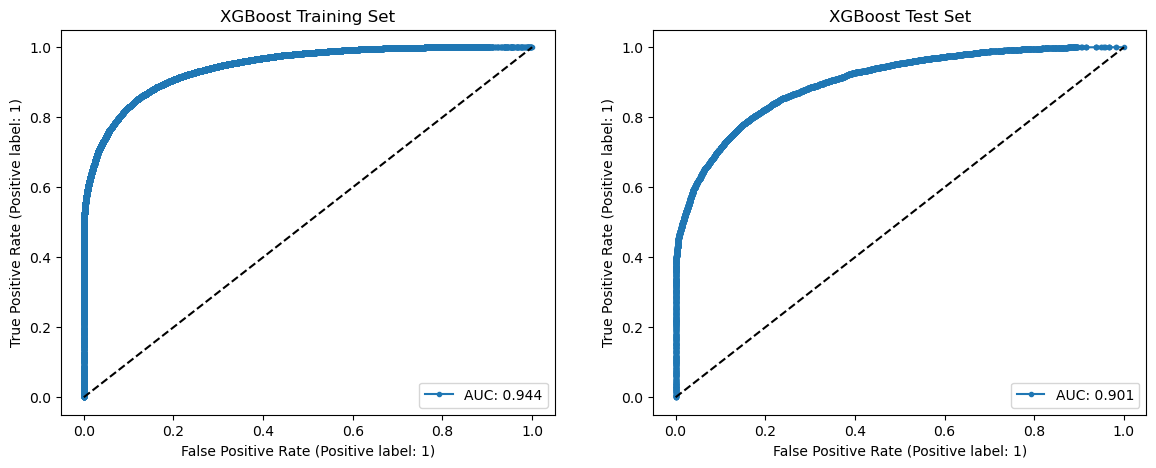

Training Set AUC: 0.944
Test Set AUC: 0.901


In [ ]:
#Predict probabilities
y_proba_train = XGBoost_model_sm.predict_proba(X_train_sm_ss)[:,1]
y_proba_test = XGBoost_model_sm.predict_proba(X_test_sm_ss)[:,1]

# Score (AUC)
xgb_auc_train = np.round(roc_auc_score(y_train_sm, y_proba_train),3)
xgb_auc_test = np.round(roc_auc_score(y_test, y_proba_test),3)

# Set up subplot structure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Labels
train_label = f"AUC: {xgb_auc_train}"
test_label = f"AUC: {xgb_auc_test}"

# Using RocCurveDisplay - pass in the fitted model, then the X data, then the y data
RocCurveDisplay.from_estimator(XGBoost_model_sm, X_train_sm_ss, y_train_sm, ax=axes[0], marker=".", label=train_label)
RocCurveDisplay.from_estimator(XGBoost_model_sm, X_test_sm_ss, y_test, ax=axes[1], marker=".", label=test_label)

axes[0].plot([0, 1], [0, 1], color="black", linestyle="--")
axes[1].plot([0, 1], [0, 1], color="black", linestyle="--")
axes[0].set_title("XGBoost Training Set")
axes[1].set_title("XGBoost Test Set")


plt.show()

print(f"Training Set AUC: {xgb_auc_train}")
print(f"Test Set AUC: {xgb_auc_test}")

The area under the curve (AUC) for the XGBoost model is 90.10% with slight overfitting as well.

Comparing the models overall scores:

| Model            | Train AUC | Test AUC | Train Score | Test Score | Precision | Recall  | f1-score |
|------------------|-----------|----------|-------------|------------|-----------|---------|----------|
| random_forest_sm3| 90.90%    | 87.70%   | 81.91%      | 80.80%     | 78.58%    | 66.88%  | 72.26%   |
| XGBoost_model_sm | 94.40%    | 90.10%   | 90.80%      | 84.33%     | 81.56%    | 75.07%  | 78.18%   |



Of my two models, the XGBoost model is showing higher overfitting for both AUC and accuracy scores, but provides a higher f1-score.  The f1-score listed here is for the test set. I will run f1-scores for both train set's to see how the overfitting compares next.

## <a id='toc3_1_4_'></a>[2.4 Compare F1-scores overfitting](#toc0_)

In [ ]:
# Random Forest Model predict classification
y_train_pred_rf3 = random_forest_sm3.predict(X_train_sm_ss)
y_test_pred_rf3 = random_forest_sm3.predict(X_test_sm_ss)

# Precision
print(f'Precision Train score: {precision_score(y_train_sm, y_train_pred_rf3)*100:0.2f}%')
print(f'Precision Test score: {precision_score(y_test, y_test_pred_rf3)*100:0.2f}%')

# Recall
print(f'Recall Train score: {recall_score(y_train_sm, y_train_pred_rf3)*100:0.2f}%')
print(f'Recall Test score: {recall_score(y_test, y_test_pred_rf3)*100:0.2f}%')

# F1-score
print(f'F1 Train score: {f1_score(y_train_sm, y_train_pred_rf3)*100:0.2f}%')
print(f'F1 Test score: {f1_score(y_test, y_test_pred_rf3)*100:0.2f}%')

Precision Train score: 87.62%
Precision Test score: 78.79%
Recall Train score: 74.75%
Recall Test score: 67.17%
F1 Train score: 80.67%
F1 Test score: 72.52%


In [ ]:
# XGBoost Model predict classification
y_train_pred_xgb = XGBoost_model_sm.predict(X_train_sm_ss)
y_test_pred_xgb = XGBoost_model_sm.predict(X_test_sm_ss)

# Precision
print(f'Precision Train score: {precision_score(y_train_sm, y_train_pred_xgb)*100:0.2f}%')
print(f'Precision Test score: {precision_score(y_test, y_test_pred_xgb)*100:0.2f}%')

# Recall
print(f'Recall Train score: {recall_score(y_train_sm, y_train_pred_xgb)*100:0.2f}%')
print(f'Recall Test score: {recall_score(y_test, y_test_pred_xgb)*100:0.2f}%')

# F1-score
print(f'F1 Train score: {f1_score(y_train_sm, y_train_pred_xgb)*100:0.2f}%')
print(f'F1 Test score: {f1_score(y_test, y_test_pred_xgb)*100:0.2f}%')

Precision Train score: 89.11%
Precision Test score: 79.54%
Recall Train score: 83.03%
Recall Test score: 73.07%
F1 Train score: 85.96%
F1 Test score: 76.17%


## <a id='toc3_1_5_'></a>[2.5 Comparing Overfitting between Random Forest and XGBoost models:](#toc0_)

**random_forest_sm3 Model:**

| Metric     | Train   | Test    | Overfitted Amount |
|------------|---------|---------|-------------------|
| Accuracy   | 81.91%  | 80.80%  | 1.11%             |
| AUC        | 90.90%  | 87.70%  | 3.20%             |
| Precision  | 87.58%  | 78.58%  | 9.00%             |
| Recall     | 74.38%  | 66.88%  | 7.50%             |
| F1 Score   | 80.44%  | 72.26%  | 8.18%             |


**XGBoost_model_sm Model:**

| Metric     | Train   | Test    | Overfitted Amount |
|------------|---------|---------|-------------------|
| Accuracy   | 90.80%  | 84.33%  | 6.47%             |
| AUC        | 94.40%  | 90.10%  | 4.30%             |
| Precision  | 89.11%  | 79.54%  | 9.57%             |
| Recall     | 83.03%  | 73.07%  | 9.96%             |
| F1 Score   | 85.96%  | 76.17%  | 9.79%             |


A model that has higher overfitting is tailoring itself too closely to the training data and therefore may not perform as well on unseen data. This could lead to unreliable predictions.
Therefore based on the overfitting between the two models, although XGBoost had a higher F1 score, accuracy, and AUC scores, it is overfitting more across all metrics compared to the random forest model.

The random forest model only is marginally lower in accuracy by 4%, AUC by ~3%, and F1-score by 4%.  The largest difference is that the random forest model is 4% lower in recall compared to the XGBoost model. However, it has less overfitting and suggest that it will likely perform more consistently on new data.

# <a id='toc4_'></a>[3. Error Analysis](#toc0_)

Moving foward with the Random Forest Model, evaluating tha confusion matrix will identify where the model is struggling the most. I may be able to identify patterns that indicate bias.

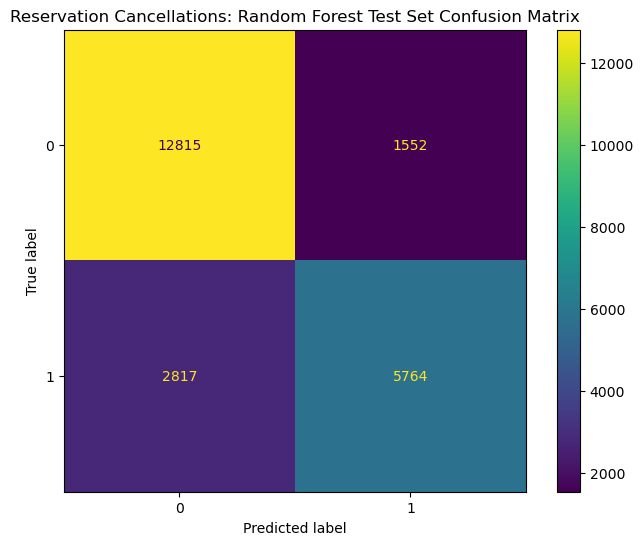

In [ ]:
# Instantiate Confusion Matrix for Random Forest Model
ConfusionMatrixDisplay.from_estimator(random_forest_sm3, X_test_sm_ss, y_test)

plt.title('Reservation Cancellations: Random Forest Test Set Confusion Matrix')
plt.show()

Based on the Test Set confusion matrix above:
- **True Negatives**: 12,800 of the data points from Class 0 were correctly predicted as reservations that would not cancel
- **False Positives**: 1500 of the reservations that the model predicted to cancel, did not cancel
- **False Negatives**: 2800 of the reservations that cancelled were missed by our model and predicted that they would not cancel
- **True Positives**: about 5800 of the cancelled reservations were correctly predicted out of the 8500 total cancellations (Precision)

In [ ]:
# Get class predictions for random_forest_sm3
y_pred_rf = random_forest_sm3.predict(X_test_sm_ss)

rf_report = classification_report(y_test, y_pred_rf)
print(rf_report)

              precision    recall  f1-score   support

           0       0.82      0.89      0.85     14367
           1       0.79      0.67      0.73      8581

    accuracy                           0.81     22948
   macro avg       0.80      0.78      0.79     22948
weighted avg       0.81      0.81      0.81     22948



## <a id='toc4_1_'></a>[3.1 Explore False Positives and False Negatives](#toc0_)


In [ ]:
# Checking prediction value
y_test_pred_rf3

array([1, 1, 1, ..., 0, 0, 0])

In [18]:
# Create new dataframe with Test
error_analysis_df = X_test.copy()
error_analysis_df

,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,is_repeated_guest,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,day_demand,los,arrival_year,arrival_month,arrival_dow,arrival_day,hotel_City Hotel,hotel_Resort Hotel,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Transient
6675,333,29,1,2,2,0,0,1,0,0,0,1,0,0,115.5,0,2,141,3,2016,7,4,15,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
69891,340,31,1,2,3,0,0,1,0,0,0,1,0,0,135.9,0,0,163,3,2017,8,4,4,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
70164,143,32,2,1,2,0,0,1,0,0,0,1,0,0,130.5,0,0,186,3,2017,8,5,12,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
59729,114,2,2,2,1,0,0,1,0,0,0,1,0,0,88.4,0,0,244,4,2017,1,5,14,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
49643,213,24,0,3,2,0,0,1,0,0,0,1,0,62,130.0,0,0,146,3,2016,6,1,7,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72067,281,30,2,2,2,0,0,1,0,0,0,1,0,0,62.0,0,0,204,4,2015,7,5,25,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1
77674,115,13,2,0,1,0,0,1,0,0,0,1,0,22,70.0,0,0,244,2,2016,3,6,20,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,1
83127,3,17,0,1,2,0,0,1,0,0,0,1,0,0,110.0,1,0,146,1,2016,4,3,21,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1
97389,19,47,1,2,2,0,0,1,0,0,0,1,0,0,88.0,0,2,207,3,2016,11,4,18,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1


In [19]:
# Add prediction column using predicted values from rf3
error_analysis_df['Prediction'] = y_test_pred_rf3

# Add back the y_test is_canceled values
error_analysis_df['Cancelled'] = y_test

#sanity check
error_analysis_df.head(5)

,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,is_repeated_guest,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,day_demand,los,arrival_year,arrival_month,arrival_dow,arrival_day,hotel_City Hotel,hotel_Resort Hotel,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Transient,Prediction,Cancelled
6675,333,29,1,2,2,0,0,1,0,0,0,1,0,0,115.5,0,2,141,3,2016,7,4,15,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,1,1
69891,340,31,1,2,3,0,0,1,0,0,0,1,0,0,135.9,0,0,163,3,2017,8,4,4,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,1,1
70164,143,32,2,1,2,0,0,1,0,0,0,1,0,0,130.5,0,0,186,3,2017,8,5,12,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,1,1
59729,114,2,2,2,1,0,0,1,0,0,0,1,0,0,88.4,0,0,244,4,2017,1,5,14,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,1,1
49643,213,24,0,3,2,0,0,1,0,0,0,1,0,62,130.0,0,0,146,3,2016,6,1,7,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1,1,1


In [20]:
# Define conditions of creating confucion matrix label column
conditions = [
    (error_analysis_df["Cancelled"] == 1) & (error_analysis_df["Prediction"] == 1),  # True Positive
    (error_analysis_df["Cancelled"] == 0) & (error_analysis_df["Prediction"] == 0),  # True Negative
    (error_analysis_df["Cancelled"] == 0) & (error_analysis_df["Prediction"] == 1),  # False Positive
    (error_analysis_df["Cancelled"] == 1) & (error_analysis_df["Prediction"] == 0)]   # False Negative

#Define values of the labels
labels = ['TP', 'TN', 'FP', 'FN']

In [21]:
# Create new column using np.select
error_analysis_df["confusion_matrix_label"] = np.select(conditions, labels)

In [22]:
# Sanity Check
error_analysis_df['confusion_matrix_label'].value_counts()

confusion_matrix_label
TN    12815
TP     5764
FN     2817
FP     1552
Name: count, dtype: int64

In [ ]:
error_analysis_df.head(5)

,lead_time,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,is_repeated_guest,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,day_demand,los,arrival_year,arrival_month,arrival_dow,arrival_day,hotel_City Hotel,hotel_Resort Hotel,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Corporate,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Transient,Prediction,Cancelled,confusion_matrix_label
6675,333,29,1,2,2,0,0,1,0,0,0,1,0,0,115.5,0,2,141,3,2016,7,4,15,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,1,1,TP
69891,340,31,1,2,3,0,0,1,0,0,0,1,0,0,135.9,0,0,163,3,2017,8,4,4,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,1,1,TP
70164,143,32,2,1,2,0,0,1,0,0,0,1,0,0,130.5,0,0,186,3,2017,8,5,12,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,1,1,TP
59729,114,2,2,2,1,0,0,1,0,0,0,1,0,0,88.4,0,0,244,4,2017,1,5,14,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,1,1,TP
49643,213,24,0,3,2,0,0,1,0,0,0,1,0,62,130.0,0,0,146,3,2016,6,1,7,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1,1,1,TP


## <a id='toc4_2_'></a>[3.2 Explore Summary Statistics by Label for each feature](#toc0_)
I want to see if there are any features that have a significant difference in the statistics between True and False Positives as well as True and False Negatives.

In [ ]:
# Create a forloop to compare summary statistics by Confusion Matrix label for each feature
for feature in error_analysis_df:
    print(f'{feature} confusion matrix statistic comparison')
    print(np.round(error_analysis_df.groupby('confusion_matrix_label')[feature].describe(),3))
    print('--------------')

lead_time confusion matrix statistic comparison
                          count     mean      std  min   25%    50%    75%  \
confusion_matrix_label                                                       
FN                       2817.0   92.897   87.643  0.0  23.0   66.0  142.0   
FP                       1552.0  109.394   84.834  0.0  41.0   88.0  164.0   
TN                      12815.0   74.804   89.789  0.0   6.0   39.0  115.0   
TP                       5764.0  168.279  124.867  0.0  68.0  140.0  256.0   

                          max  
confusion_matrix_label         
FN                      518.0  
FP                      542.0  
TN                      542.0  
TP                      629.0  
--------------
arrival_date_week_number confusion matrix statistic comparison
                          count    mean     std  min   25%   50%    75%   max
confusion_matrix_label                                                       
FN                       2817.0  27.795  13.720  1.0  17.

A few features stuck out with a larger difference between the True and False values

lead_time:
- FP mean: 108.88
- TP mean: 167.81

previous_bookings_not_canceled:
- FN mean: 0.074
- TN mean: 0.216

booking_changes:
- FP mean: 0.118
- TP mean: 0.041

days_in_waiting_list: 
- FP mean: 1.308
- TP mean: 4.758

## <a id='toc4_3_'></a>[3.2 Box Plot Distribution Exploration](#toc0_)

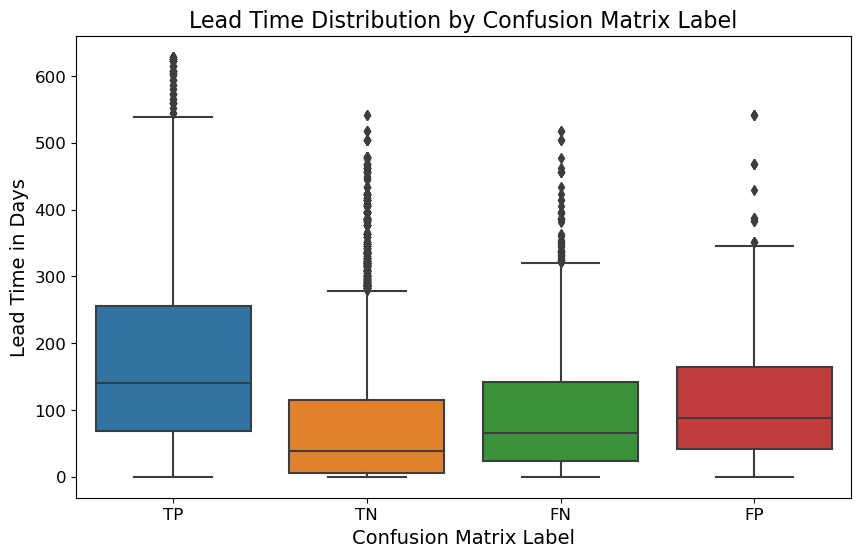

In [ ]:
# Distribution by Leadtime
# Set the figure size
plt.figure(figsize=(10, 6))

# Create the box plot
sns.boxplot(
    x='confusion_matrix_label',  # Categorical variable on the x-axis
    y='lead_time',               # Numeric variable on the y-axis
    data=error_analysis_df
)

# Customize the plot for clarity
plt.title('Lead Time Distribution by Confusion Matrix Label', fontsize=16)
plt.xlabel('Confusion Matrix Label', fontsize=14)
plt.ylabel('Lead Time in Days', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

When looking at the Lead Time distribution, the Mean of True Positives are above 100 days whereas the mean for False Positives are below 100 days. This suggests that the model struggles with reservations that have shorter lead times (<100 days).  This indicates that the feature lead time may play a role in the models distinguishing true positives from false positives.

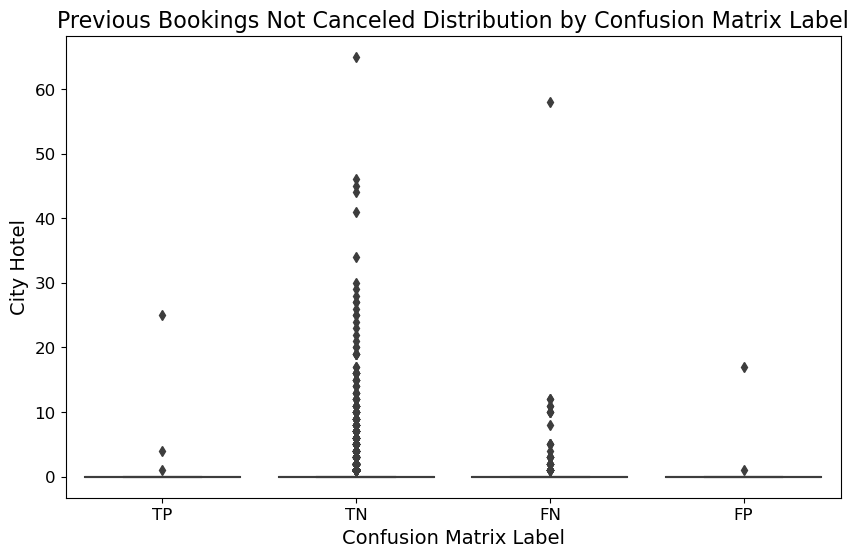

In [26]:
# Distribution by previous_bookings_not_canceled
# Set the figure size
plt.figure(figsize=(10, 6))

# Create the box plot
sns.boxplot(
    x='confusion_matrix_label',  
    y='previous_bookings_not_canceled',             
    data=error_analysis_df
)

# Customize the plot for clarity
plt.title('Previous Bookings Not Canceled Distribution by Confusion Matrix Label', fontsize=16)
plt.xlabel('Confusion Matrix Label', fontsize=14)
plt.ylabel('City Hotel', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

There are not clear insights on this plot. There are all outliers and difficult to get insights from this feature.

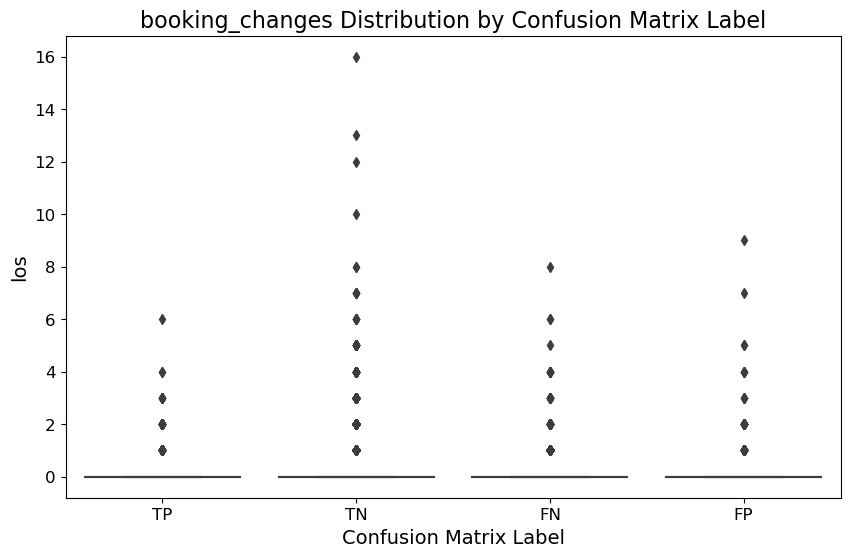

In [27]:
# Distribution by booking_changes
# Set the figure size
plt.figure(figsize=(10, 6))

# Create the box plot
sns.boxplot(
    x='confusion_matrix_label',  # Categorical variable on the x-axis
    y='booking_changes',               # Numeric variable on the y-axis
    data=error_analysis_df
)

# Customize the plot for clarity
plt.title('booking_changes Distribution by Confusion Matrix Label', fontsize=16)
plt.xlabel('Confusion Matrix Label', fontsize=14)
plt.ylabel('los', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

Similar to the previoius plot for Previous Bookings Not Canceled, the booking changes plot does not provide not clear insights either. There are all outliers and difficult to get insights from this feature.

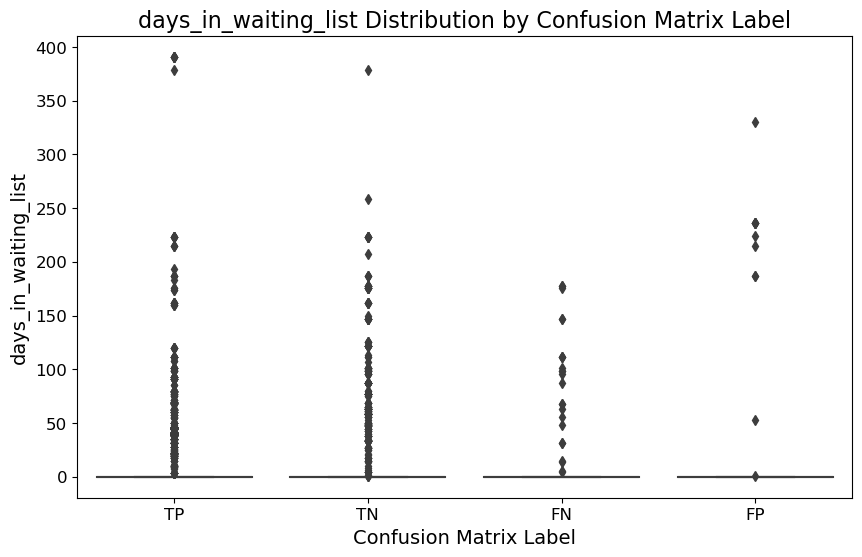

In [28]:
# Distribution by days_in_waiting_list
# Set the figure size
plt.figure(figsize=(10, 6))

# Create the box plot
sns.boxplot(
    x='confusion_matrix_label',                 # Categorical variable on the x-axis
    y='days_in_waiting_list',               # Numeric variable on the y-axis
    data=error_analysis_df
)

# Customize the plot for clarity
plt.title('days_in_waiting_list Distribution by Confusion Matrix Label', fontsize=16)
plt.xlabel('Confusion Matrix Label', fontsize=14)
plt.ylabel('days_in_waiting_list', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

Again, this is similar to the previoius 2 plots and does not provide not clear insights either. There are all outliers and difficult to get insights from this feature.

The only insightful feature I have found so far is `lead_time.` 

For future iterations of error analysis I could explore the following:
- Set limits to these features to remove the outliers
- Bin the features by ranges so the data is more insightful


# <a id='toc5_'></a>[4. Feature Importance](#toc0_)

## <a id='toc5_1_1_'></a>[4.1 Random Forest Permutation Feature Importance:](#toc0_)

In [ ]:
%%time

# Determine random forest feature importance using the test set
# Repeat the permuation step 5 times per column.
rf_result = permutation_importance(random_forest_sm3, X_test_ss_sm, y_test, n_repeats=5, random_state=0)

CPU times: user 5min 27s, sys: 1.36 s, total: 5min 29s
Wall time: 5min 33s


In [33]:
# Calculate the average importance per feature for Random Forest Model
importances = rf_result.importances_mean

# Normalize the importances
normalized_importances = importances / importances.sum()


# Put the variable names and their feature importances into a data frame
rf_permute_importances_df = pd.DataFrame({'Variable': X_train.columns,
                               'Importance': importances,
                               'Normalized Importance': normalized_importances})

rf_permute_importances_df.sort_values(by='Importance', ascending=False, inplace=True, ignore_index=True)

rf_permute_importances_df

,Variable,Importance,Normalized Importance
0,total_of_special_requests,0.072939,0.225221
1,market_segment_Offline TA/TO,0.036796,0.113620
2,deposit_type_No Deposit,0.036369,0.112301
3,lead_time,0.032883,0.101537
4,hotel_City Hotel,0.022059,0.068113
5,deposit_type_Non Refund,0.019758,0.061008
6,hotel_Resort Hotel,0.012620,0.038968
7,required_car_parking_spaces,0.009700,0.029952
8,market_segment_Online TA,0.009308,0.028741
9,booking_changes,0.009125,0.028176


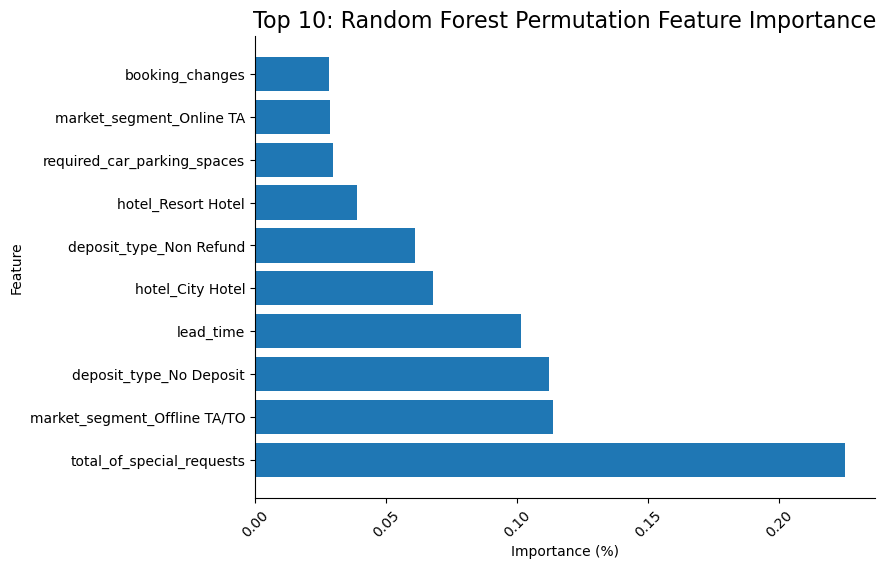

In [34]:
# Plot the importances

 # Top 10: Random Forest Permutation Feature Importance
plt.barh(rf_permute_importances_df['Variable'].head(10), rf_permute_importances_df['Normalized Importance'].head(10))
plt.title('Top 10: Random Forest Permutation Feature Importance', fontsize=16)
plt.ylabel('Feature')
plt.xlabel('Importance (%)')
plt.xticks(rotation = 45)
sns.despine()

plt.show()

The most important feature in our Random Forest model is total_of_special_requests with an importance over 20%.  How Permutation Importance is determined is that each feature is evaluated both before and after a feature is manipulated or removed. Based on those evaluations, the higher the model's error increases after the feature is manipulated, the more important that feature is.

## <a id='toc5_2_'></a>[4.2 Shapley Values](#toc0_)

Due to computational limitations with the random forest model and the depth of trees, I instead determined SHAP values using the XGBoost model.  This will provide potentially similar results to my random forest model.

In [35]:
%%time
# This calculation might take 2-3 minutes!

# Fit tree-specific kernel for SHAP
explainer = shap.TreeExplainer(XGBoost_model_sm) 


CPU times: user 86.3 ms, sys: 34.7 ms, total: 121 ms
Wall time: 24.2 ms


In [36]:
# Obtain SHAP values
shap_values = explainer.shap_values(X_train_sm_ss)

In [37]:
shap_values.shape

(114934, 42)

Global Interpretation:

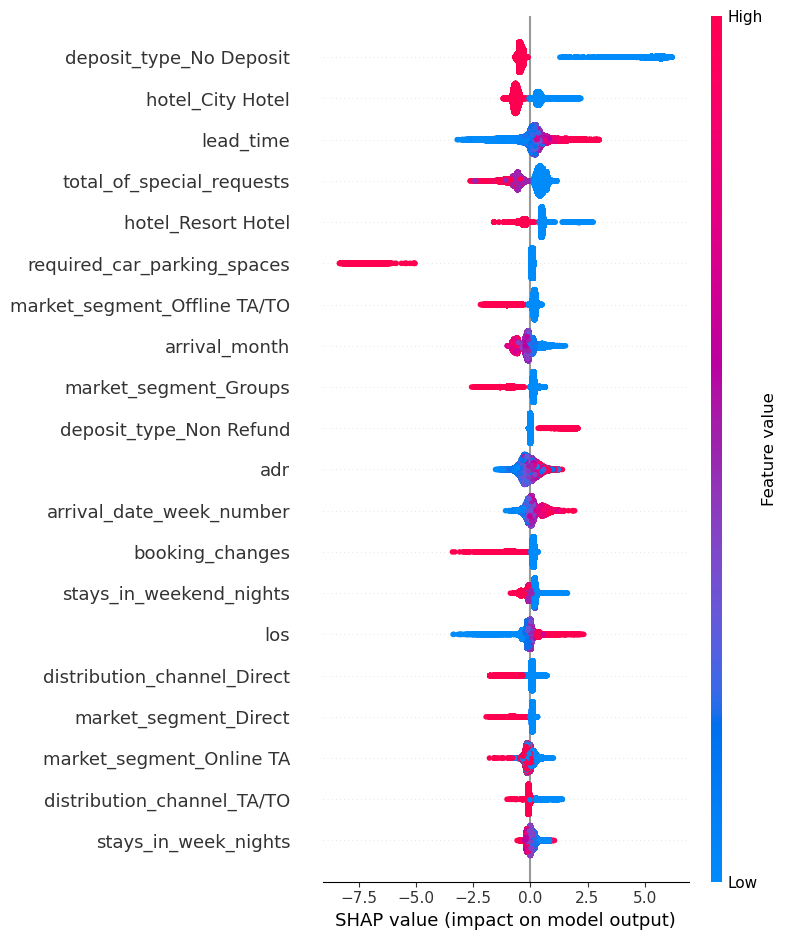

In [40]:
# Global interpretation - summary plot - type = 'dot'
shap.initjs()

shap.summary_plot(shap_values, features=X_train_sm_ss, feature_names=X_train_sm.columns)

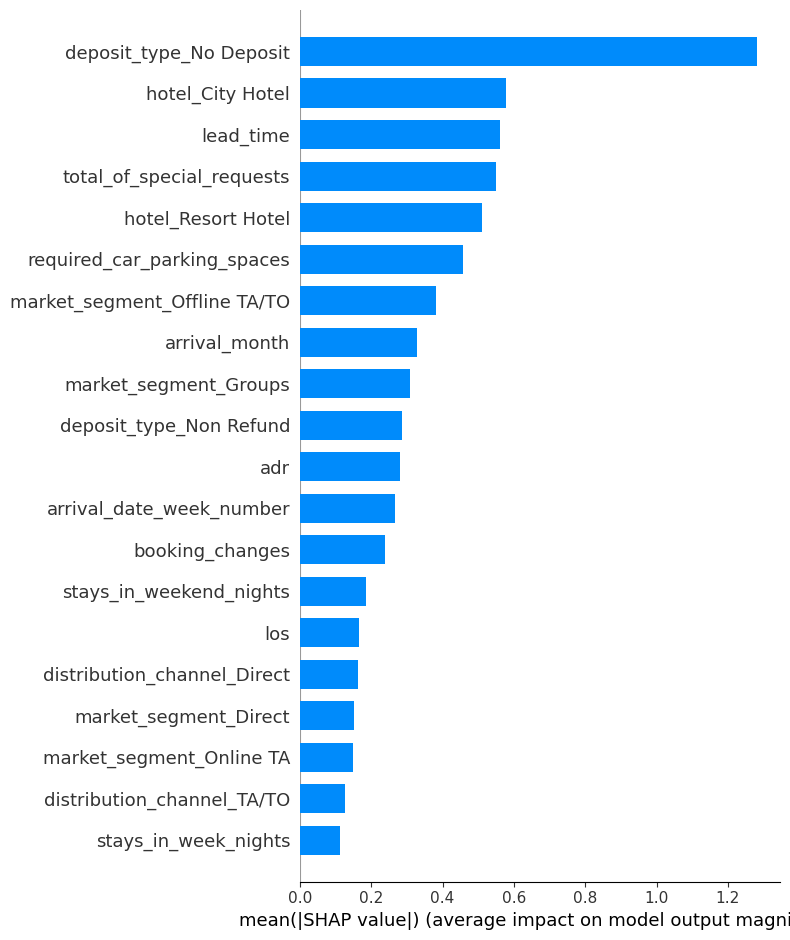

In [41]:
# Global interpretation - summary plot - type='bar'
shap.initjs()

shap.summary_plot(shap_values, features=X_train_sm_ss, feature_names=X_train_sm.columns, plot_type='bar')

The summary and bar plots of SHAP values above both indicate the the most impactful features are similar to what the permutation feature importance revealed. The top 4 features were the same, just in a different order of importance.  This could be due to the fact that I substituted the Random Forest model with the XGBoost model, however, it is good to see consistency between both methods and models.

Dependence Plot

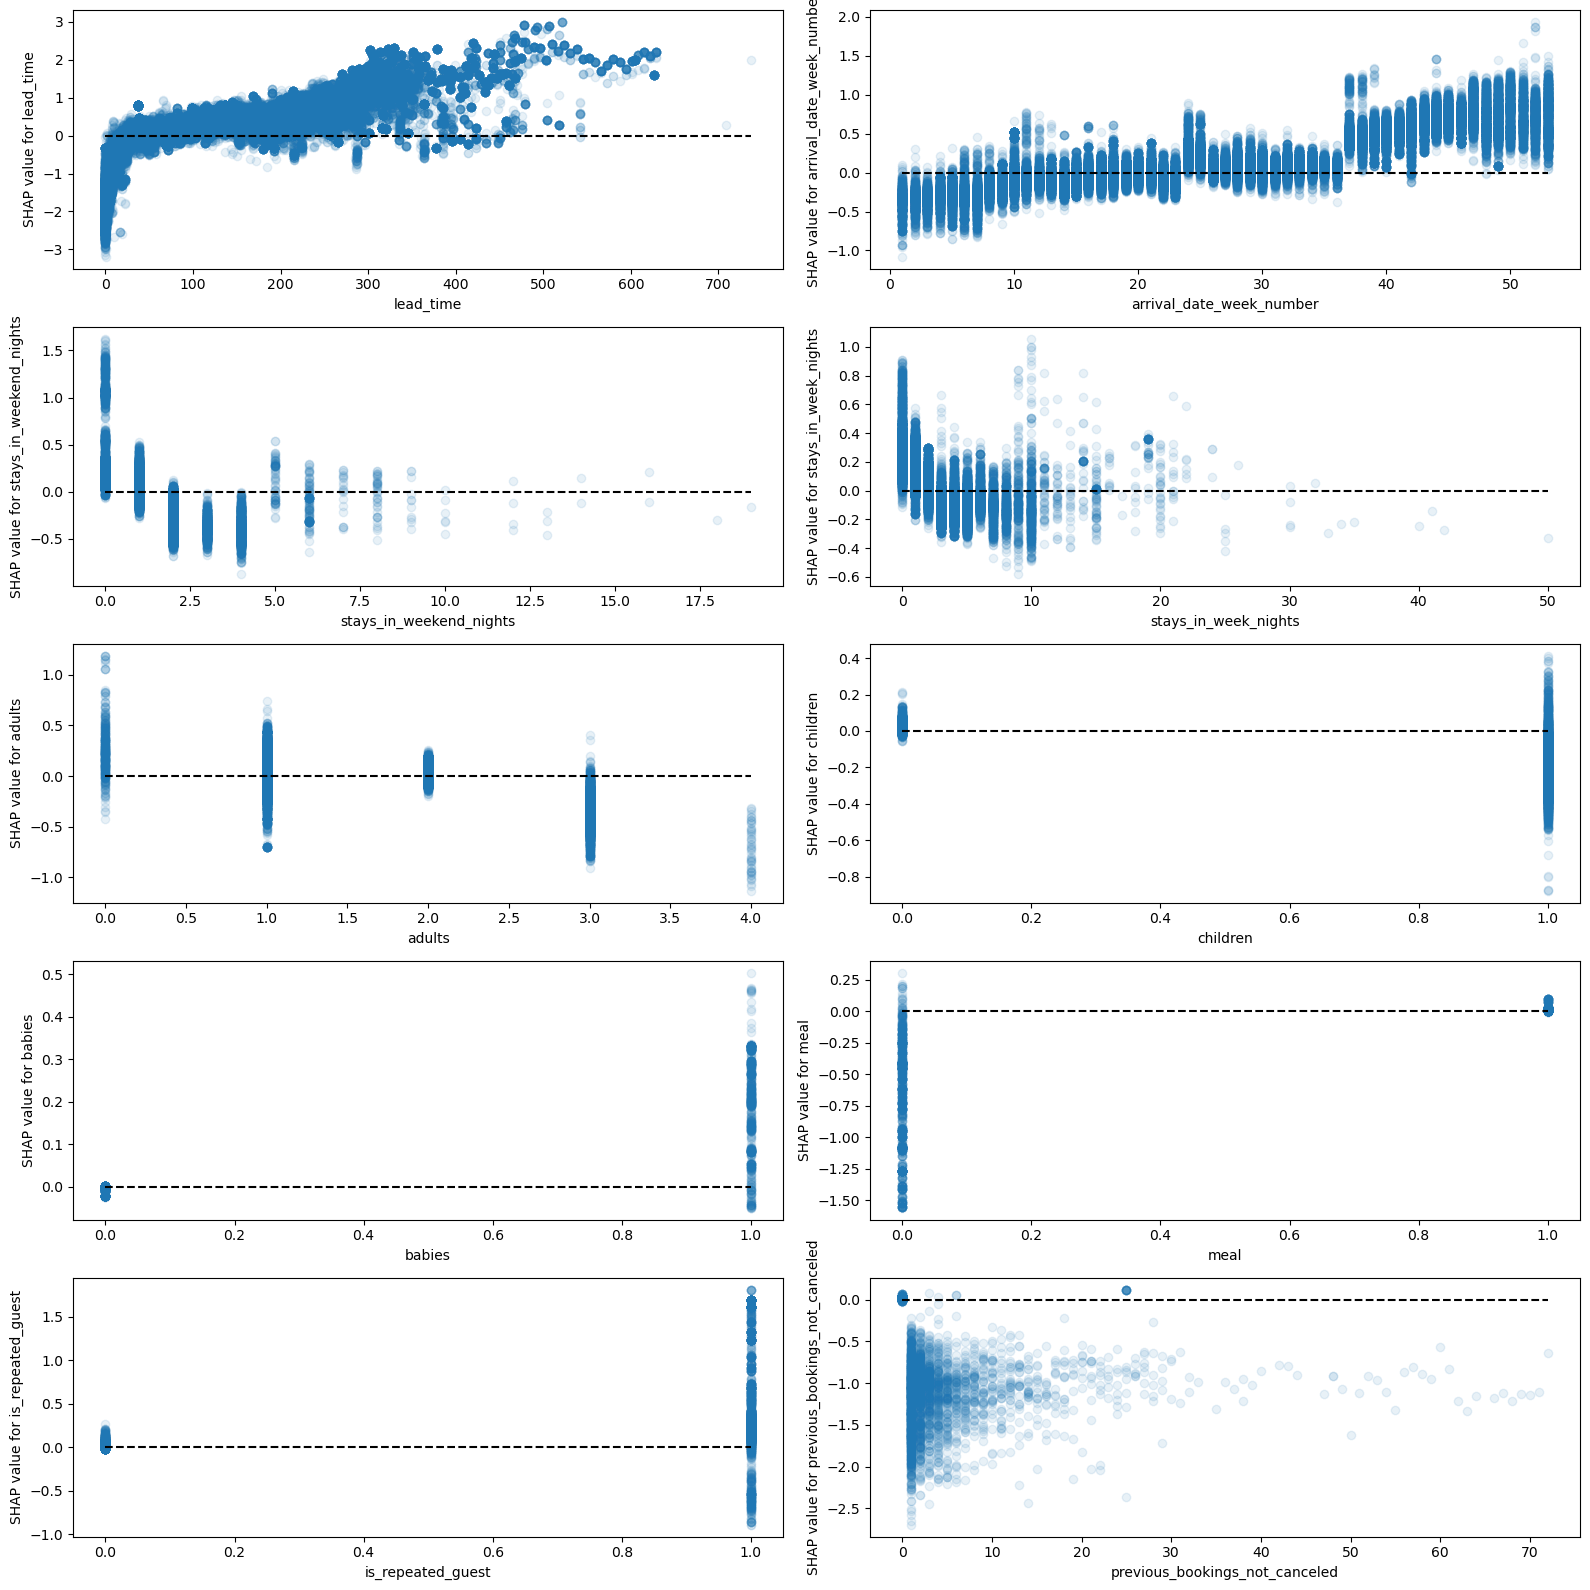

In [42]:
# Create DataFrame for Shapley values easier plotting
shap_df = pd.DataFrame(shap_values, columns=X_train_sm.columns)

columns = shap_df.iloc[:,:10]

# Plot SHAP Dependence Plots for each feature
plt.subplots(5,2, figsize=(16,16))

for i, col in enumerate(columns.columns):
  plt.subplot(5,2,i+1)
  plt.scatter(X_train_sm[col], shap_df[col], alpha=0.1)
  plt.hlines(y=0, xmin=X_train_sm[col].min(), xmax=X_train_sm[col].max(), colors='black', linestyles='--')
  plt.xlabel(col)
  plt.ylabel(f'SHAP value for {col}')

plt.tight_layout()
plt.show()

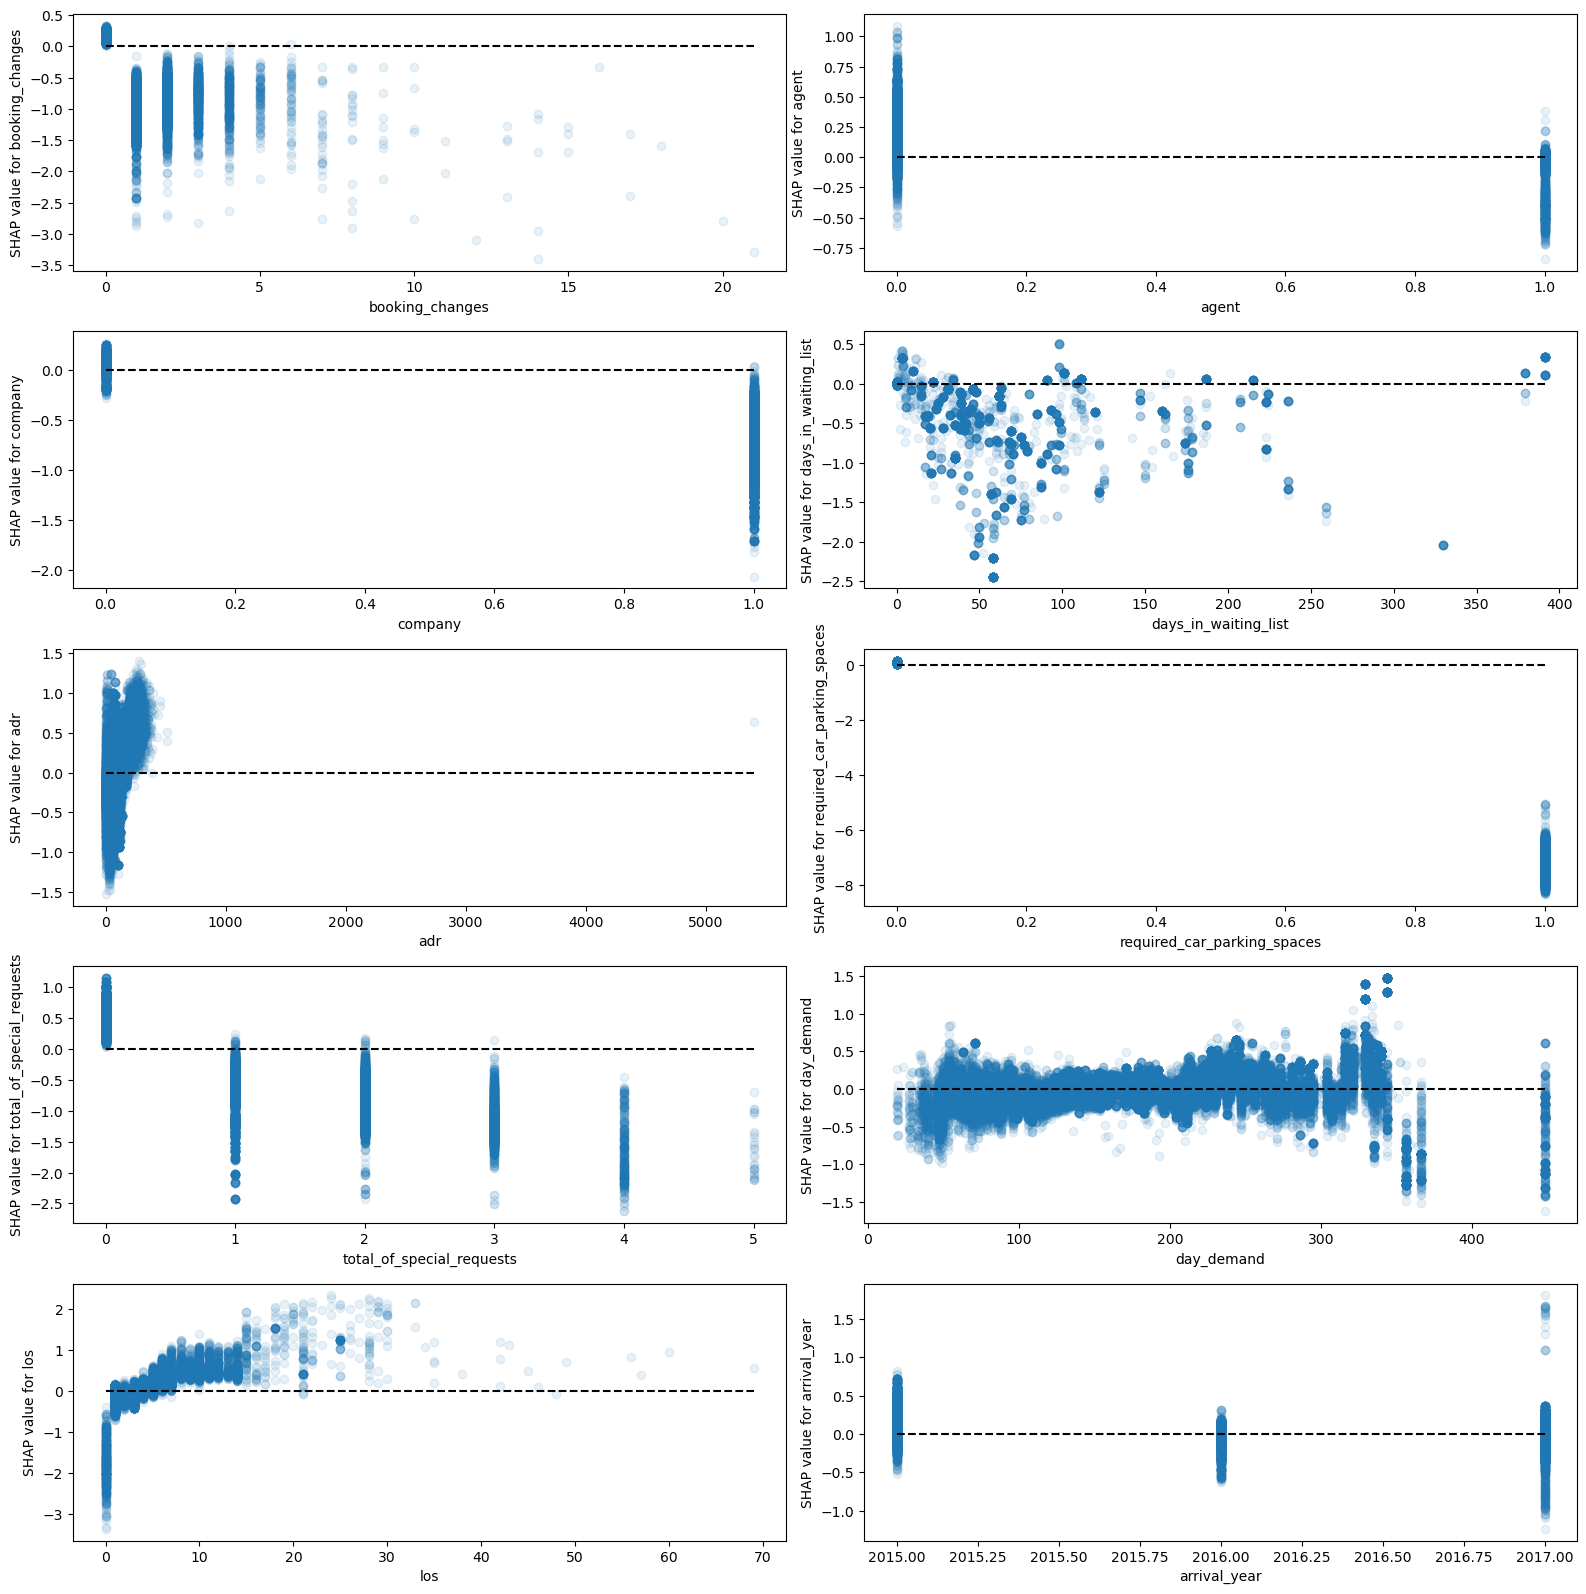

In [43]:
# Create DataFrame for Shapley values easier plotting
shap_df = pd.DataFrame(shap_values, columns=X_train_sm.columns)

columns = shap_df.iloc[:,10:20]

# Plot SHAP Dependence Plots for each feature
plt.subplots(5,2, figsize=(16,16))

for i, col in enumerate(columns.columns):
  plt.subplot(5,2,i+1)
  plt.scatter(X_train_sm[col], shap_df[col], alpha=0.1)
  plt.hlines(y=0, xmin=X_train_sm[col].min(), xmax=X_train_sm[col].max(), colors='black', linestyles='--')
  plt.xlabel(col)
  plt.ylabel(f'SHAP value for {col}')

plt.tight_layout()
plt.show()

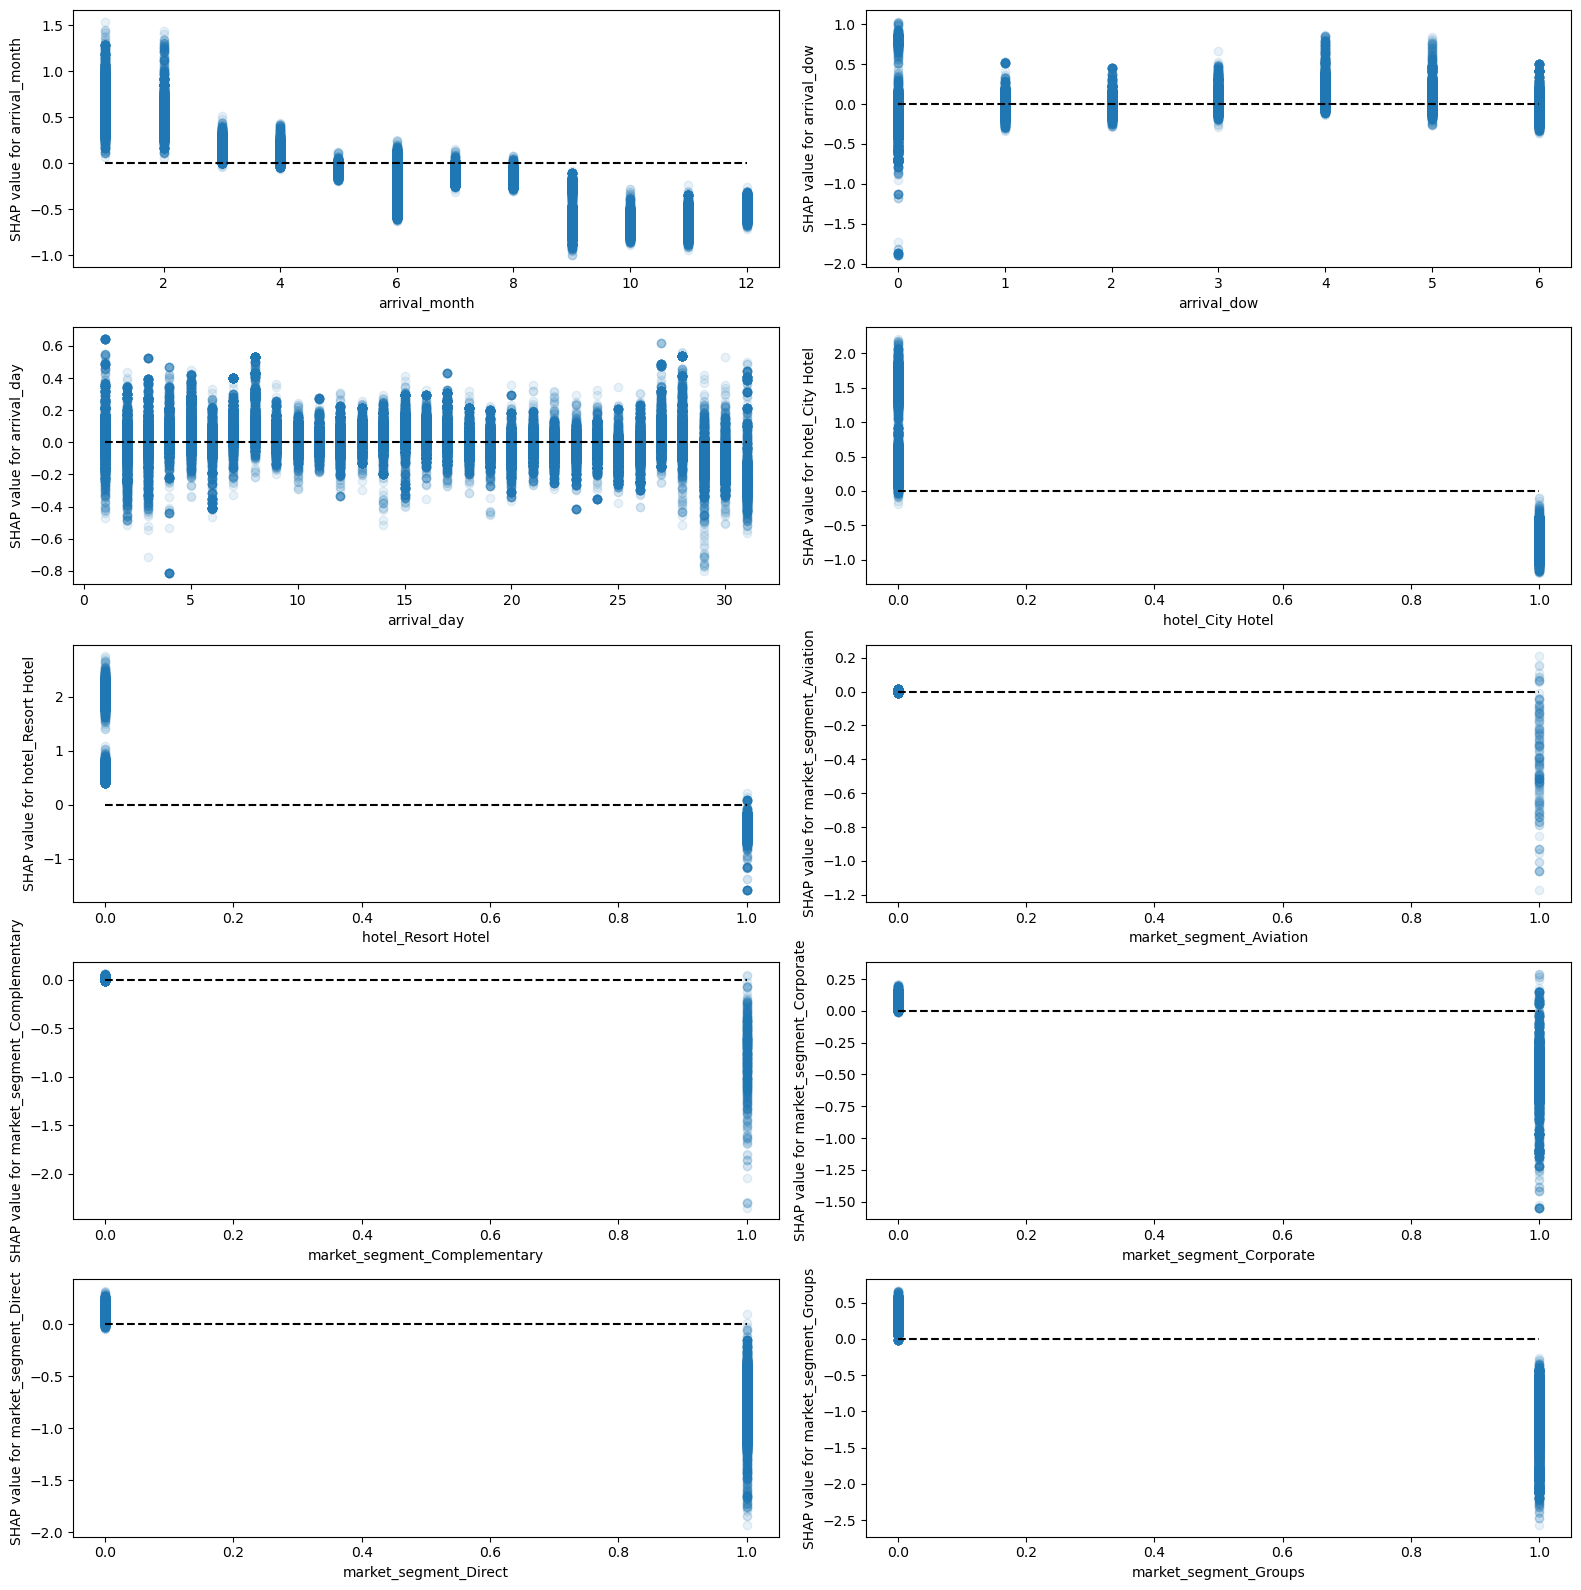

In [44]:
# Create DataFrame for Shapley values easier plotting
shap_df = pd.DataFrame(shap_values, columns=X_train_sm.columns)

columns = shap_df.iloc[:,20:30]

# Plot SHAP Dependence Plots for each feature
plt.subplots(5,2, figsize=(16,16))

for i, col in enumerate(columns.columns):
  plt.subplot(5,2,i+1)
  plt.scatter(X_train_sm[col], shap_df[col], alpha=0.1)
  plt.hlines(y=0, xmin=X_train_sm[col].min(), xmax=X_train_sm[col].max(), colors='black', linestyles='--')
  plt.xlabel(col)
  plt.ylabel(f'SHAP value for {col}')

plt.tight_layout()
plt.show()

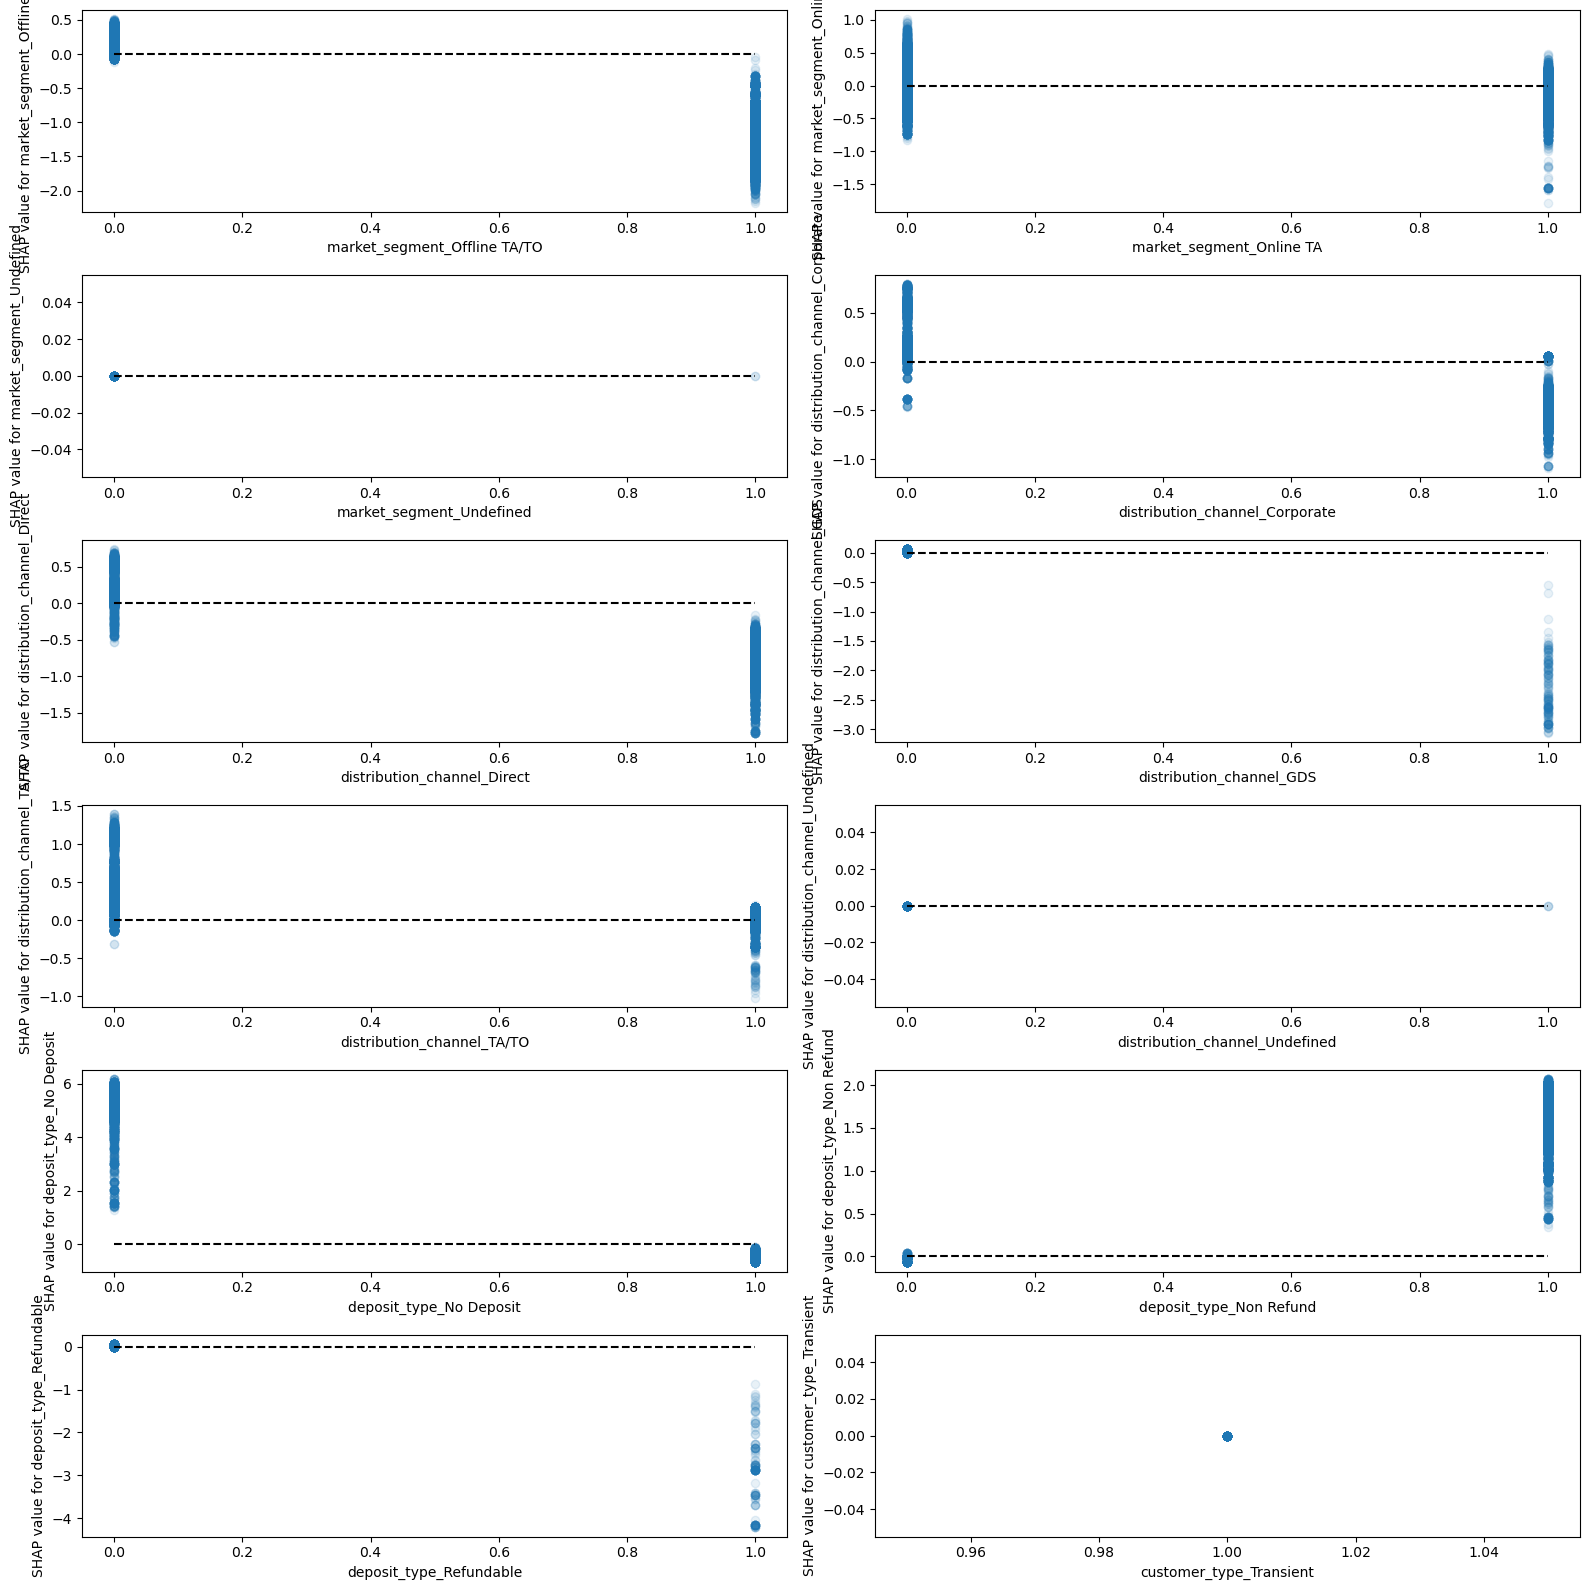

In [ ]:
# Create DataFrame for Shapley values easier plotting
shap_df = pd.DataFrame(shap_values, columns=X_train_sm.columns)

columns = shap_df.iloc[:,30:]

# Plot SHAP Dependence Plots for each feature
plt.subplots(6,2, figsize=(16,16))

for i, col in enumerate(columns.columns):
  plt.subplot(6,2,i+1)
  plt.scatter(X_train_sm[col], shap_df[col], alpha=0.1)
  plt.hlines(y=0, xmin=X_train_sm[col].min(), xmax=X_train_sm[col].max(), colors='black', linestyles='--')
  plt.xlabel(col)
  plt.ylabel(f'SHAP value for {col}')

plt.tight_layout()
plt.show()

As SHAP values are positive, this indicates that reservations of that feature contribute positively toward the likelihood of a cancellation. The lower or negative SHAP values suggest that the reservation is less likely to cancel.

While looking at these features, a few stuck out to me:

Lead Time:
- The shorter the lead time, the less likely reservations will cancel
- The farther out the lead time, the more likely they will cancel


los (length of stay):
- The shorter the LOS, the less likely guests will cancel
- As the LOS increases past 5, the more likely reservations will cancel


Arrival Date Week Number:
- The earlier in the year, the less likely reservations will cancel
- The later half in the year, reservations are more likely to cancel. This could possible be due to holiday and plans changing as well as weather impacting travel


Arrival_month:
- The earlier the arrival month (between 1-4) the SHAP values are higher and therefore reservations are more likely to cancel. As the year passes, month 6-12 show less likely to cancel.  This is interesting because this is opposite of the arrival date week number feature.

The fact that the two arrival features displaying inverse SHAP values is intriguing.  I would expect both of them to share a similar trend.  For potential next steps, I would evaluate additional possible overfitting or model complexity as the model may be focusing too much on individual weeks vs. the broader monthly patterns and trends.


# <a id='toc6_'></a>[5. Summary](#toc0_)

**Final Model Performance: random_forest_sm3:**

| Metric     | Train   | Test    | Overfitted Amount |
|------------|---------|---------|-------------------|
| Accuracy   | 81.91%  | 80.80%  | 1.11%             |
| AUC        | 90.90%  | 87.70%  | 3.20%             |
| Precision  | 87.58%  | 78.58%  | 9.00%             |
| Recall     | 74.38%  | 66.88%  | 7.50%             |
| F1 Score   | 80.44%  | 72.26%  | 8.18%             |


Model Selection:
- I ultimately chose the Random Forest model because it is only marginally lower in accuracy by 4%, AUC by ~3%, and F1-score by 4%.  The largest difference is that the random forest model is 4% lower in recall compared to the XGBoost model. However, it has less overfitting and suggests that it will likely perform more consistently on new data. A model that has higher overfitting is tailoring itself too closely to the training data and therefore may not perform as well on unseen data. This could lead to unreliable predictions.

Final Model Evaluation:
- When evaluating the confusion matrix, I found that out of the 8500 total reservations that cancelled, the model predicted 1500 reservations to cancel, but they actually did not cancel. And the model predicted 2800 reservations would not cancel, but they actually did cancel.
- Recall: Of all the cancelled reservations (8581), the model correctly predicted 5764 reservations correctly
- Precision: Out of the 7316 reservations the model said were going to cancel, 5764 reservations actually cancelled?

--- 
To better understand the tradeoff between precision and recall:

- Low Precision: If the model incorrectly predict a reservation to cancel, and the hotel sells that room twice in anticipation of that cancellation, then the hotel will have increased costs. (walking the guest + guest dissatisfaction)

- Low Recall: If the model misses predicting a reservatino will cancel, the hotel will have unsold rooms.

---

- I further explored these errors in the model using box plot distributions and the most insightful feature I discovered that the model struggles with is lead time. The model’s average of true positives (accurately predicting a cancellation) were above 100 days, whereas the model’s average false positives (predicting a cancellation, but the reservation did not cancel) was below 100 days. This suggests that the model may struggle with reservations that have shorter lead times.

- When evaluating feature importance I utilized both permutation feature importance and SHAP.  The top 4 features permutation features importance were `total_special_requests`, `market_segment_offiline TA/TO`, `deposit_type_No Deposit`, and `lead_time`.

- I attempted to run Shapley values on the random forest model as well, however due to computational limitations with the model type and depth of trees, I substituted with the XGBoost model. This will provide similar results to my random forest model as the top 4 most important features were the same, just in a different order.

- When diving deeper into dependency plots of the SHAP values, I noticed the lead time’s pattern the most, where the shorter the lead time, the less likely the reservations are going to cancel. One interesting discovery I found over, is that between the 2 arrival features (Arrival Date Week Number and Arrival Month), they displayed inverse SHAP values. I would expect both of them to share a similar trend.  To investigate this further, I would evaluate additional possible overfitting or investigate my model complexity as the model may be focusing too much on individual weeks vs. the broader monthly patterns and trends.

Overall Project Next Steps:
- I chose my first workflow to take my domain knowledge and experience working with hotel cancellation forecasts out of the equation. I chose to do this so that I could have an unbaised evaluation of a dataset first before apply my domain knowledge into the model.  Perhaps my past experience was a bias, therefore I wanted to have a true end to end experience working with a dataset to see what I could uncover.  
    - With that in mind, my next iteration would include feature engineering and removal of some features that I truly did not believe would have any impact on predicting cancellations (such as `children`, `babies`, `meal`). 
    - I would also use my domain knowledge and bring back features such as `reserved_room_type` and `assigned_room_type` and apply one hot encoding to those features.  My 'unbiased' approach felt that this would have created too many features, however, I believe the type of room reserved strongly plays a role in demand and may also play a role in predicting cancellations.
- Return to feature engineering and remove stays in weekday nights and stay in weekend nights due to redundancy now that I have length of stay (los).
- Binning length of stay (`los`) and `lead_time` into smaller groupings to reduce complexity and help the model learn better.
